In [583]:
import sys
# Add parent directory to path to import file_paths module
sys.path.insert(0, '..')
import file_paths
import helper_functions

import eelbrain
import mne
import numpy as np
import scipy.io
import matplotlib.pyplot as plt



SUBJECT = 'S1'
TRIAL = 4
SENSOR = 'Cz'
TSTOP = 10.00  # Python indexing is exclusive of the specified stop sample 

# Fuglsang preprocessing pipeline

## EEG PREPROC

In [584]:
samplingrate = 64

# Create Biosemi montage with mastoids
montage = mne.channels.make_standard_montage('biosemi64')
#montage.plot()
ch_names = montage.ch_names + ['EXG1', 'EXG2']  # include mastoids
ch_types = ['eeg'] * 64 + ['misc', 'misc']  # mastoids are misc
info = mne.create_info(ch_names, samplingrate, ch_types)
info.set_montage(montage, on_missing='ignore')  # mastoids not in standard montage

<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, AF7, AF3, F1, F3, F5, F7, FT7, FC5, FC3, FC1, C1, C3, C5, ...
 chs: 64 EEG, 2 misc
 custom_ref_applied: False
 dig: 67 items (3 Cardinal, 64 EEG)
 highpass: 0.0 Hz
 lowpass: 32.0 Hz
 meas_date: unspecified
 nchan: 66
 projs: []
 sfreq: 64.0 Hz
>

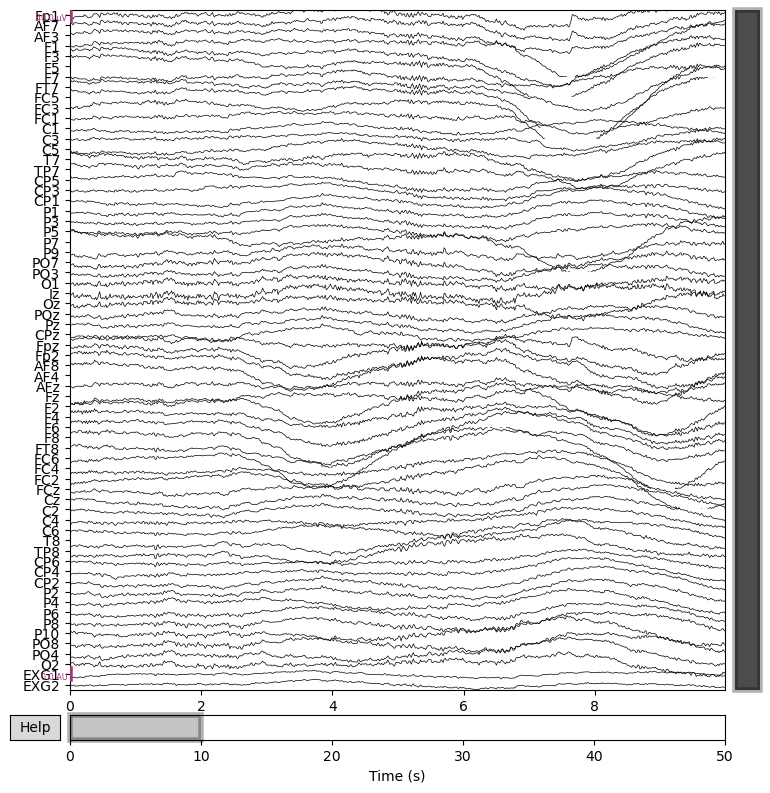

done


In [585]:
# --- Load MATLAB data ---
subject_data_file = helper_functions.get_subject_data_file(SUBJECT)
mat = scipy.io.loadmat(subject_data_file, squeeze_me=True, struct_as_record=False)
data = mat['data']

trial = data.eeg[TRIAL]

eeg = np.array(trial).T
raw = mne.io.RawArray(eeg * 1e-6, info, verbose=False)  # convert µV → V

raw.plot(block = True, n_channels=len(raw.ch_names))
print("done")

### Raw EEG

EEG:  <NDVar: 64 sensor, 640 time>
EEG sensor names:  ['Fp1', 'AF7', 'AF3', 'F1', 'F3', 'F5', 'F7', 'FT7', 'FC5', 'FC3', 'FC1', 'C1', 'C3', 'C5', 'T7', 'TP7', 'CP5', 'CP3', 'CP1', 'P1', 'P3', 'P5', 'P7', 'P9', 'PO7', 'PO3', 'O1', 'Iz', 'Oz', 'POz', 'Pz', 'CPz', 'Fpz', 'Fp2', 'AF8', 'AF4', 'AFz', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT8', 'FC6', 'FC4', 'FC2', 'FCz', 'Cz', 'C2', 'C4', 'C6', 'T8', 'TP8', 'CP6', 'CP4', 'CP2', 'P2', 'P4', 'P6', 'P8', 'P10', 'PO8', 'PO4', 'O2']
EEG from sensor:  <NDVar: 640 time>


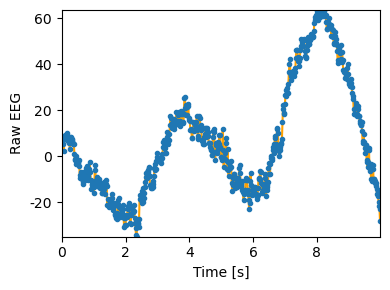

In [586]:
eeg = eelbrain.load.mne.raw_ndvar(raw) # load MNE Raw into Eelbrain NDVar
eeg = eeg.sub(time=(0, TSTOP)) # crop the data for this demonstration
sensor_eeg = eeg.sub(sensor=SENSOR) # select one sensor for this demonstration

print("EEG: ", eeg)
print("EEG sensor names: ", eeg.get_dim('sensor').names)
print("EEG from sensor: ", sensor_eeg)

# --- Raw EEG ---
fig1, ax1 = plt.subplots(figsize=(4, 3))
eelbrain.plot.UTS(sensor_eeg, axes=ax1, ylabel='Raw EEG')
ax1.set_ylim(sensor_eeg.min(), sensor_eeg.max())

t = sensor_eeg.time
y = sensor_eeg.x
ax1.plot(t, y, 'o', markersize=3)

fig1.tight_layout()

### Re-reference

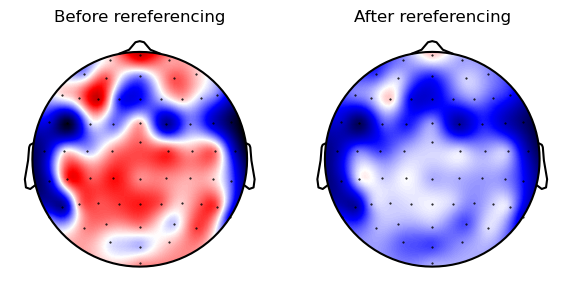

In [587]:

# Preprocessing
raw.set_eeg_reference(['EXG1', 'EXG2'])      # average mastoids

eeg_ref = eelbrain.load.mne.raw_ndvar(raw) # load MNE Raw into Eelbrain NDVar
eeg_ref = eeg_ref.sub(time=(0, TSTOP))


# Average over time
eeg_mean = eeg.mean('time')
eeg_ref_mean = eeg_ref.mean('time')


# Plot
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

eelbrain.plot.Topomap(eeg_mean, axes=axes[0], clip='circle')
eelbrain.plot.Topomap(eeg_ref_mean, axes=axes[1], clip='circle')

# Set titles via matplotlib
axes[0].set_title('Before rereferencing')
axes[1].set_title('After rereferencing')

fig.tight_layout()

### Band pass filter

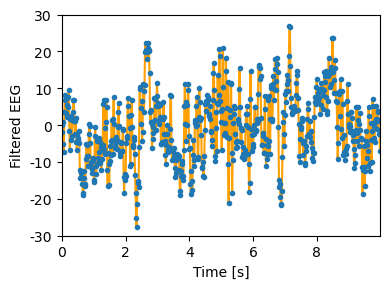

In [588]:
raw.filter(0.5, 20, verbose=False) # band-pass
eeg_filtered = eelbrain.load.mne.raw_ndvar(raw) # load MNE Raw into Eelbrain NDVar
eeg_filtered = eeg_filtered.sub(time=(0, TSTOP)) # crop the data for this demonstration
eeg_filtered = eeg_filtered.sub(sensor=SENSOR) # select the same sensor as before


# --- Filtered EEG ---
fig2, ax2 = plt.subplots(figsize=(4, 3))
eelbrain.plot.UTS(eeg_filtered, axes=ax2, ylabel='Filtered EEG')

t = eeg_filtered.time
y = eeg_filtered.x
ax2.plot(t, y, 'o', markersize=3)

fig2.tight_layout()

## EEG plot after preprocessing

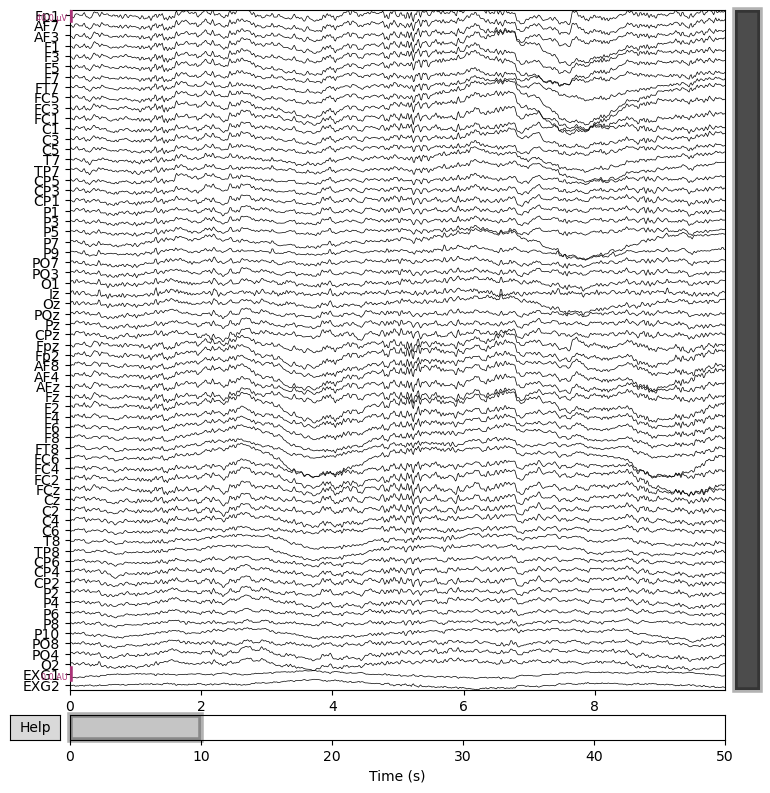

done


In [589]:
raw.plot(block = True, n_channels=len(raw.ch_names))
print("done")

## Audio Preprocessing

In [590]:
# --- Load MATLAB data ---
subject_data_file = helper_functions.get_subject_data_file(SUBJECT)
mat = scipy.io.loadmat(subject_data_file, squeeze_me=True, struct_as_record=False)
data = mat['data']

### Envelopes

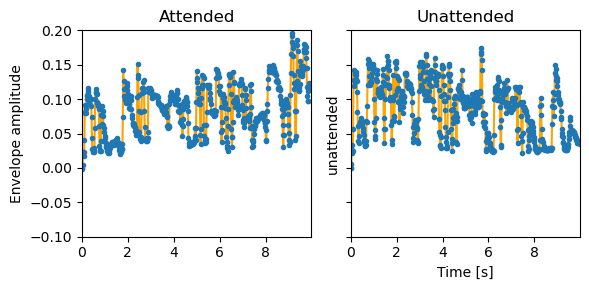

In [591]:
att_envelope = data.wavA[TRIAL]
unatt_envelope = data.wavB[TRIAL]

time_axis = eelbrain.UTS(0, 1 / data.fsample.wavA, len(att_envelope))

att_ndvar = eelbrain.NDVar(att_envelope, dims=(time_axis,), name='attended')
unatt_ndvar = eelbrain.NDVar(unatt_envelope, dims=(time_axis,), name='unattended')

att_ndvar = att_ndvar.sub(time=(0, TSTOP))
unatt_ndvar = unatt_ndvar.sub(time=(0, TSTOP))

# --- Plot attended and unattended envelopes ---
fig, ax = plt.subplots(1, 2, figsize=(6, 3))

eelbrain.plot.UTS(att_ndvar, axes=ax)
eelbrain.plot.UTS(unatt_ndvar, axes=ax[1], color='orange')

# overlay markers
ax[0].plot(att_ndvar.time, att_ndvar.x, 'o', markersize=3)
ax[1].plot(unatt_ndvar.time, unatt_ndvar.x, 'o', markersize=3)

ax[0].set_title('Attended')
ax[1].set_title('Unattended')
ax[0].set_ylabel('Envelope amplitude')

fig.tight_layout()